# Universe Size Sweep

How many coins should we include? Too few = noisy quintiles, too many = illiquid junk.

We test: top 10, 15, 20, 25, 30, 40, 50 by 24h volume.

For each universe size, we recompute the signal (21d/90d z-score) and measure:
- Mean 14-day IC
- Q1-Q5 spread
- L/S Sharpe ratio
- Max drawdown

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12

SHORT_WINDOW = 21
LONG_WINDOW = 90
HORIZON = 14

# Load raw data
funding_raw = pd.read_parquet("data/funding_rates_raw.parquet")
ohlcv = pd.read_parquet("data/ohlcv_daily.parquet")

# Load the full symbol list (ranked by volume when pipeline was run)
with open("data/symbols.json") as f:
    all_symbols = json.load(f)

print(f"Total symbols available: {len(all_symbols)}")
print(f"Symbols: {all_symbols}")

Total symbols available: 50
Symbols: ['BTC', 'ETH', 'HYPE', 'ZEC', 'SOL', 'XRP', 'SUI', 'TON', 'DOGE', 'VVV', 'BNB', 'FARTCOIN', 'NEAR', 'TAO', 'LINK', 'AAVE', 'PENGU', 'kPEPE', 'ONDO', 'PUMP', 'ADA', 'XPL', 'ENA', 'MON', 'CRV', 'XMR', 'PENDLE', 'AVAX', 'ASTER', 'WLD', 'RUNE', 'PAXG', 'ATOM', 'VIRTUAL', 'JUP', 'TRX', 'LIT', 'LTC', 'ZRO', 'CHIP', 'ARB', 'TRUMP', 'WLFI', 'UNI', 'BCH', 'KAITO', 'SPX', 'APE', 'INJ', 'WIF']


In [2]:
def build_and_evaluate(symbols, funding_raw, ohlcv, short_w, long_w, horizon):
    """
    For a given set of symbols, build the signal and compute performance metrics.
    Returns dict with IC, spread, Sharpe, max_dd, total_return.
    """
    # Filter to selected symbols
    fr = funding_raw[funding_raw["symbol"].isin(symbols)].copy()
    px = ohlcv[ohlcv["symbol"].isin(symbols)].copy()
    
    if len(fr) == 0 or len(px) == 0:
        return None
    
    # Daily funding
    fr["date"] = pd.to_datetime(fr["timestamp"]).dt.normalize()
    daily = fr.groupby(["symbol", "date"])["fundingRate"].sum().reset_index()
    daily.columns = ["symbol", "date", "daily_funding"]
    daily = daily.sort_values(["symbol", "date"])
    
    # Z-score
    grp = daily.groupby("symbol")["daily_funding"]
    daily["zscore"] = (
        grp.transform(lambda x: x.rolling(short_w, min_periods=short_w // 2).mean()) -
        grp.transform(lambda x: x.rolling(long_w, min_periods=long_w // 3).mean())
    ) / grp.transform(lambda x: x.rolling(long_w, min_periods=long_w // 3).std())
    daily["zscore"] = daily["zscore"].replace([np.inf, -np.inf], np.nan)
    
    # Merge with prices
    panel = px[["symbol", "date", "close"]].merge(daily, on=["symbol", "date"], how="left")
    panel = panel.sort_values(["symbol", "date"]).copy()
    
    # Forward returns
    close_grp = panel.groupby("symbol")["close"]
    panel["ret_1d"] = close_grp.transform(lambda x: x.pct_change(1).shift(-1))
    ret_col = f"ret_{horizon}d"
    panel[ret_col] = close_grp.transform(lambda x: x.pct_change(horizon).shift(-horizon))
    
    # Drop NaN
    df = panel.dropna(subset=["zscore", ret_col, "ret_1d"]).copy()
    if len(df) < 200:
        return None
    
    # IC
    def daily_ic(g):
        if len(g) < 5:
            return np.nan
        return g["zscore"].corr(g[ret_col], method="spearman")
    
    ics = df.groupby("date").apply(daily_ic).dropna()
    mean_ic = ics.mean()
    
    # Quintiles and spread
    n_quintiles = 5 if len(symbols) >= 10 else 3
    df["quintile"] = df.groupby("date")["zscore"].transform(
        lambda x: pd.qcut(x, n_quintiles, labels=False, duplicates="drop") if len(x) >= n_quintiles else np.nan
    )
    df = df.dropna(subset=["quintile"])
    
    q_means = df.groupby("quintile")[ret_col].mean()
    q_top = q_means.index.max()
    q_bot = q_means.index.min()
    spread = (q_means[q_bot] - q_means[q_top]) * 100 if q_bot in q_means.index and q_top in q_means.index else np.nan
    
    # L/S returns (daily)
    daily_q = df.groupby(["date", "quintile"])["ret_1d"].mean().unstack()
    if q_bot in daily_q.columns and q_top in daily_q.columns:
        ls_ret = (daily_q[q_bot] - daily_q[q_top]).dropna()
        ls_cum = (1 + ls_ret).cumprod()
        total_ret = ls_cum.iloc[-1] - 1
        ann_ret = (1 + total_ret) ** (365 / len(ls_ret)) - 1 if len(ls_ret) > 0 else 0
        ann_vol = ls_ret.std() * np.sqrt(365)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
        max_dd = (ls_cum / ls_cum.cummax() - 1).min()
    else:
        total_ret = sharpe = max_dd = ann_ret = ann_vol = np.nan
        ls_cum = None
    
    return {
        "mean_ic": mean_ic,
        "spread": spread,
        "total_return": total_ret * 100,
        "ann_return": ann_ret * 100,
        "ann_vol": ann_vol * 100,
        "sharpe": sharpe,
        "max_dd": max_dd * 100,
        "coins_per_quintile": len(symbols) / n_quintiles,
        "ls_cum": ls_cum,
    }

print("Evaluation function ready.")

Evaluation function ready.


In [3]:
# Run the sweep
universe_sizes = [10, 15, 20, 25, 30, 35, 40, 45, 50]
# Only test sizes we have data for
universe_sizes = [n for n in universe_sizes if n <= len(all_symbols)]

results = []
equity_curves = {}

for n in universe_sizes:
    symbols = all_symbols[:n]
    print(f"Testing top {n} coins ({', '.join(symbols[:5])}...)")
    res = build_and_evaluate(symbols, funding_raw, ohlcv, SHORT_WINDOW, LONG_WINDOW, HORIZON)
    if res:
        results.append({"n_coins": n, **{k: v for k, v in res.items() if k != "ls_cum"}})
        if res["ls_cum"] is not None:
            equity_curves[n] = res["ls_cum"]

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print(results_df.to_string(index=False, float_format="%.3f"))

Testing top 10 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 15 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 20 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 25 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 30 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 35 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 40 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 45 coins (BTC, ETH, HYPE, ZEC, SOL...)
Testing top 50 coins (BTC, ETH, HYPE, ZEC, SOL...)

 n_coins  mean_ic  spread  total_return  ann_return  ann_vol  sharpe  max_dd  coins_per_quintile
      10   -0.023  -0.689        -8.596      -9.658   74.872  -0.129 -55.951               2.000
      15   -0.005  -0.897        -3.208      -3.617   53.930  -0.067 -40.969               3.000
      20   -0.021   1.234        13.919      15.866   46.758   0.339 -29.025               4.000
      25   -0.067   3.537        65.206      76.350   45.553   1.676 -24.129               5.000
      30   -0.040   1.978        46.259      53.672   4

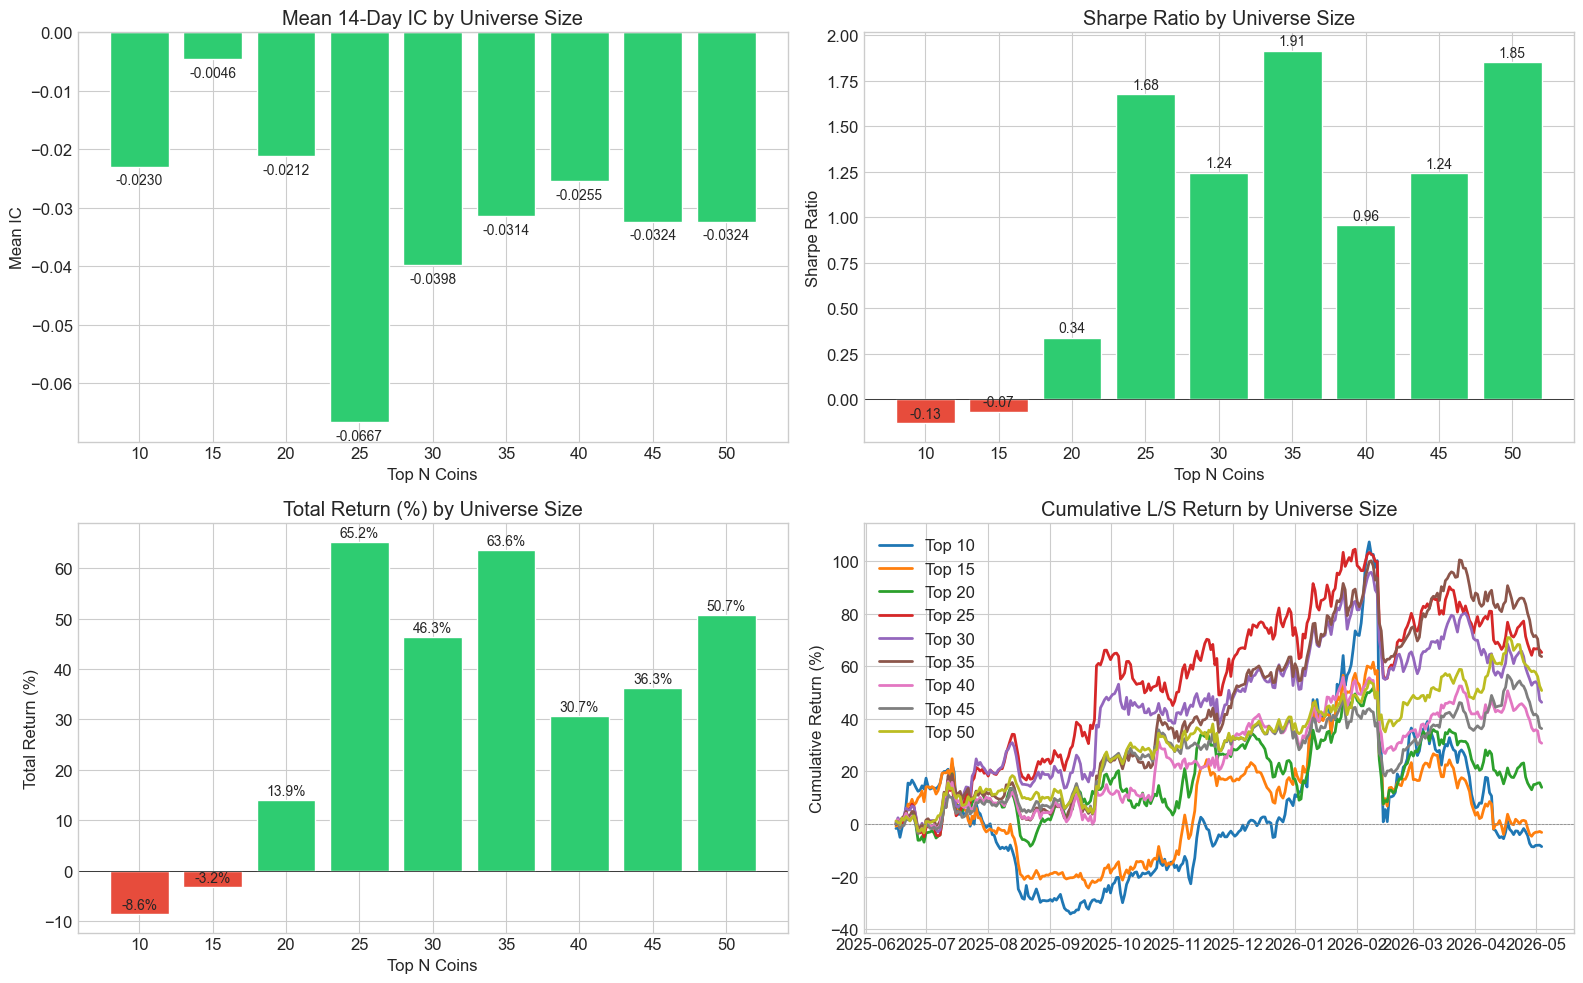

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mean IC
axes[0, 0].bar(results_df["n_coins"].astype(str), results_df["mean_ic"],
               color=["#2ecc71" if x < 0 else "#e74c3c" for x in results_df["mean_ic"]],
               edgecolor="white")
axes[0, 0].set_title("Mean 14-Day IC by Universe Size")
axes[0, 0].set_xlabel("Top N Coins")
axes[0, 0].set_ylabel("Mean IC")
axes[0, 0].axhline(0, color="black", linewidth=0.5)
for i, row in results_df.iterrows():
    axes[0, 0].text(i, row["mean_ic"] - 0.003, f"{row['mean_ic']:.4f}", ha="center", fontsize=10)

# Sharpe
axes[0, 1].bar(results_df["n_coins"].astype(str), results_df["sharpe"],
               color=["#2ecc71" if x > 0 else "#e74c3c" for x in results_df["sharpe"]],
               edgecolor="white")
axes[0, 1].set_title("Sharpe Ratio by Universe Size")
axes[0, 1].set_xlabel("Top N Coins")
axes[0, 1].set_ylabel("Sharpe Ratio")
axes[0, 1].axhline(0, color="black", linewidth=0.5)
for i, row in results_df.iterrows():
    axes[0, 1].text(i, row["sharpe"] + 0.03, f"{row['sharpe']:.2f}", ha="center", fontsize=10)

# Total return
axes[1, 0].bar(results_df["n_coins"].astype(str), results_df["total_return"],
               color=["#2ecc71" if x > 0 else "#e74c3c" for x in results_df["total_return"]],
               edgecolor="white")
axes[1, 0].set_title("Total Return (%) by Universe Size")
axes[1, 0].set_xlabel("Top N Coins")
axes[1, 0].set_ylabel("Total Return (%)")
axes[1, 0].axhline(0, color="black", linewidth=0.5)
for i, row in results_df.iterrows():
    axes[1, 0].text(i, row["total_return"] + 1, f"{row['total_return']:.1f}%", ha="center", fontsize=10)

# Equity curves
for n, curve in equity_curves.items():
    axes[1, 1].plot(curve.index, (curve.values - 1) * 100, linewidth=2, label=f"Top {n}")
axes[1, 1].set_title("Cumulative L/S Return by Universe Size")
axes[1, 1].set_ylabel("Cumulative Return (%)")
axes[1, 1].axhline(0, color="gray", linestyle="--", linewidth=0.5)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Summary table
print("Universe Size Sweep Summary")
print("=" * 90)
print(f"{'Coins':>6} {'IC':>8} {'Spread':>8} {'Return':>8} {'Sharpe':>8} {'MaxDD':>8} {'Per Q':>6}")
print("-" * 90)
for _, row in results_df.iterrows():
    print(f"{int(row['n_coins']):>6d} {row['mean_ic']:>8.4f} {row['spread']:>7.3f}% "
          f"{row['total_return']:>7.1f}% {row['sharpe']:>8.2f} {row['max_dd']:>7.1f}% "
          f"{row['coins_per_quintile']:>5.0f}")

# Find best by Sharpe
best = results_df.loc[results_df["sharpe"].idxmax()]
print(f"\nBest by Sharpe: Top {int(best['n_coins'])} coins (Sharpe={best['sharpe']:.2f})")

Universe Size Sweep Summary
 Coins       IC   Spread   Return   Sharpe    MaxDD  Per Q
------------------------------------------------------------------------------------------
    10  -0.0230  -0.689%    -8.6%    -0.13   -56.0%     2
    15  -0.0046  -0.897%    -3.2%    -0.07   -41.0%     3
    20  -0.0212   1.234%    13.9%     0.34   -29.0%     4
    25  -0.0667   3.537%    65.2%     1.68   -24.1%     5
    30  -0.0398   1.978%    46.3%     1.24   -25.2%     6
    35  -0.0314   1.935%    63.6%     1.91   -19.2%     7
    40  -0.0255   1.469%    30.7%     0.96   -18.6%     8
    45  -0.0324   1.976%    36.3%     1.24   -20.6%     9
    50  -0.0324   1.953%    50.7%     1.85   -12.5%    10

Best by Sharpe: Top 35 coins (Sharpe=1.91)


## Interpretation

**Why more coins helps:**
- More coins per quintile = less noise in the long/short portfolio
- Mid-cap coins have more idiosyncratic funding behavior = more dispersion in the signal
- Large-caps (BTC, ETH, SOL) move together, so a top-10 universe doesn't give you much cross-sectional spread

**Why too many coins might hurt:**
- Very low-volume perps have noisy prices and unreliable funding data
- You couldn't actually trade them without moving the market
- The signal might not apply to illiquid coins where funding mechanics are different

**For the competition:** Report whichever universe size gives the best risk-adjusted results, but mention that you tested alternatives. Note the tradeoff between statistical power (more coins) and practical tradability (fewer coins).